**Catálogos de Sismicidad**

In [12]:
from obspy import UTCDateTime
from obspy.clients.fdsn import Client
client = Client("USGS")
t1 = UTCDateTime("2012-03-01T00:00:00")
t2 = UTCDateTime("2012-04-01T00:00:00")
catalog = client.get_events(starttime=t1, endtime=t2, catalog="",
minlatitude=-39, maxlatitude=-34, minlongitude=-76, maxlongitude=-71,
minmagnitude=5)
print(catalog)
catalog.write("events.zmap", format="ZMAP") #ascii
catalog.write("events.kml", format="KML") #google earth


2 Event(s) in Catalog:
2012-03-25T22:37:06.000000Z | -35.200,  -72.217 | 7.1  mww | manual
2012-03-03T22:12:55.000000Z | -35.749,  -72.800 | 5.0  mwr | manual


1 Trace(s) in Stream:
C.GO05..BHZ | 2012-03-25T22:37:06.000000Z - 2012-03-25T22:37:33.500000Z | 40.0 Hz, 1101 samples


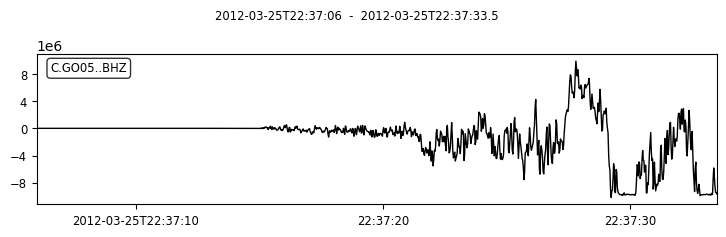

In [2]:
from obspy import UTCDateTime
from obspy.clients.fdsn import Client
client = Client("EARTHSCOPE")
t = UTCDateTime("2012-03-25T22:37:06")
st = client.get_waveforms("C", "GO05", "*", "BHZ", t, t + 600)
print (st)
f1 = st.plot()

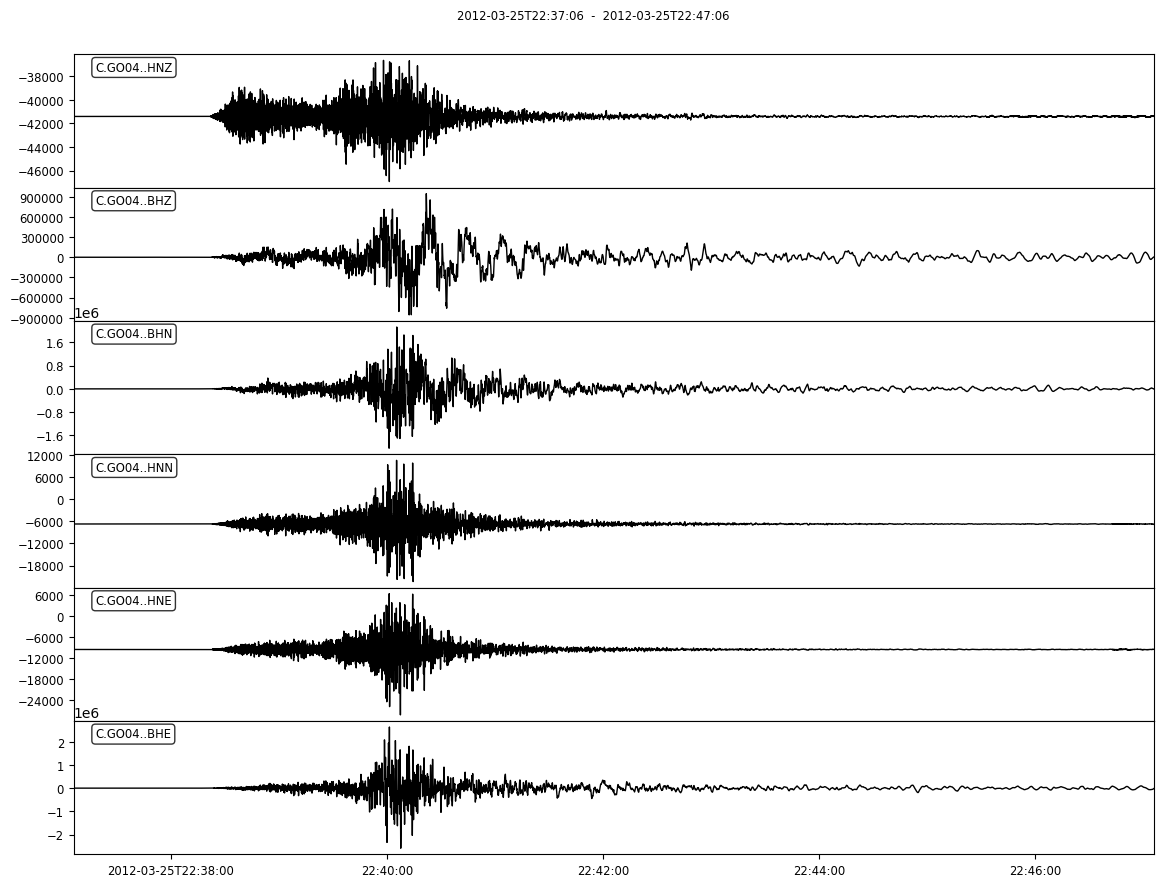

In [ ]:
from obspy import UTCDateTime
from obspy.clients.fdsn import Client
client = Client("EARTHSCOPE")
t = UTCDateTime("2012-03-25T22:37:06")
st = client.get_waveforms("C", "GO04", "*", "BH?,HN?", t, t + 600)
f2 = st.plot(equal_scale=False, size=(1200, 900), number_of_ticks=5, show_y_UTC_label=True)

¡Sismos encontrados!
1 Event(s) in Catalog:
2010-02-27T06:34:11.530000Z | -36.122,  -72.898 | 8.8  mww | manual


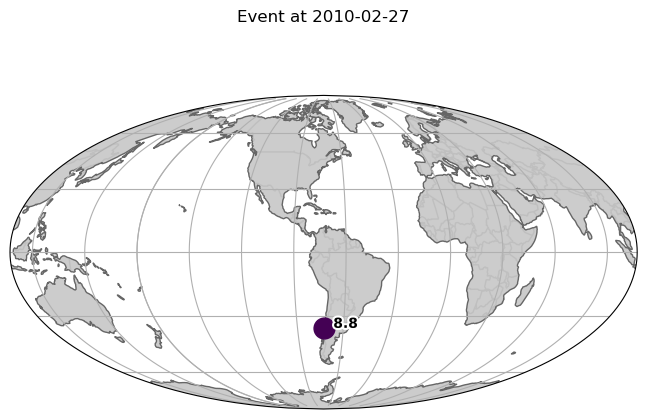

In [2]:
from obspy.clients.fdsn import Client
from obspy import UTCDateTime

# 1. Nos conectamos al servidor principal de sismología (IRIS/EarthScope)
client = Client("USGS")

# 2. Definimos una fecha de inicio y fin para buscar
tiempo_inicio = UTCDateTime("2010-02-01")
tiempo_fin = UTCDateTime("2010-03-01")

# 3. Buscamos sismos de magnitud mayor a 8.0 en esa fecha 
# (¡A ver si adivinas qué sismo de Chile va a encontrar!)
catalogo = client.get_events(starttime=tiempo_inicio, endtime=tiempo_fin, minmagnitude=8.0)

print("¡Sismos encontrados!")
print(catalogo)

# 4. ¡Magia! Le pedimos a ObsPy que nos dibuje el mapa
out = catalogo.plot()

2 Event(s) in Catalog:
2015-01-27T05:27:46.000000Z | -36.852,  -73.632 | 4.7  mb | manual
2015-01-27T02:40:06.000000Z | -36.850,  -73.583 | 4.6  mwr | manual


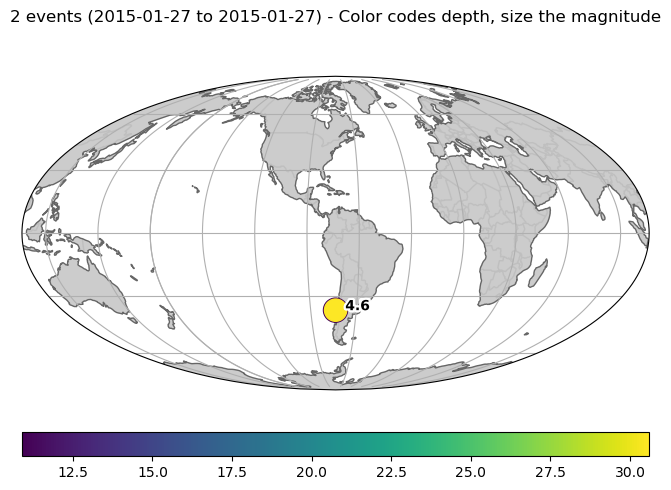

In [ ]:
from obspy.clients.fdsn import Client
from obspy import UTCDateTime
client = Client("USGS") # USGS para obtener eventos a nivel mundial

ti = UTCDateTime("2015-01-1T00:00:00")
tf = UTCDateTime("2015-01-31T23:59:59")
catalogo = client.get_events(starttime=ti, endtime=tf, minmagnitude=4.0, minlatitude=-45, maxlatitude=-35, minlongitude=-75, maxlongitude=-70)

print(catalogo)

out = catalogo.plot()

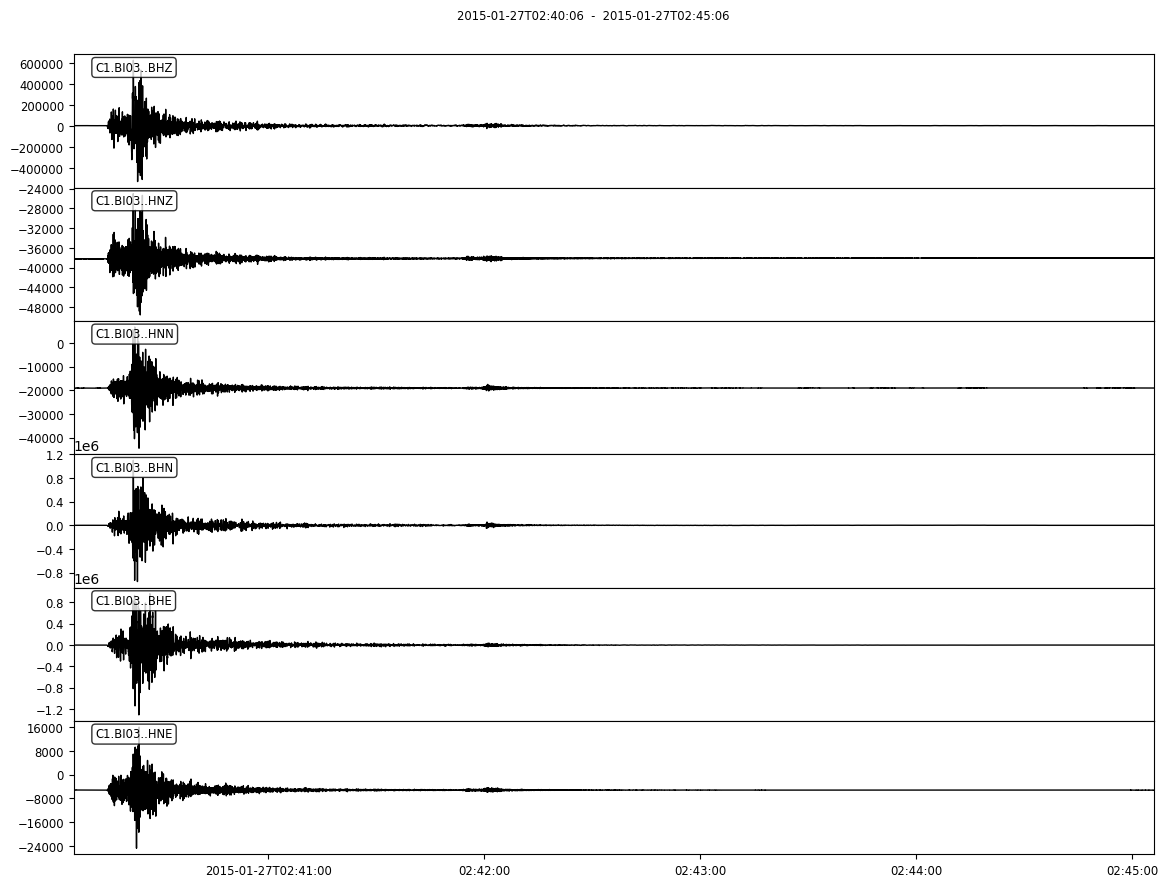

In [ ]:
from obspy import UTCDateTime
from obspy.clients.fdsn import Client
client = Client("IRIS") # IRIS para obtener datos de estaciones sísmicas de todo el mundo

t = UTCDateTime("2015-01-27T02:40:06")

st = client.get_waveforms("C1", "BI03", "*", "BH?,HN?", t, t + 300)

f3 = st.plot(equal_scale=False, size=(1200, 900), number_of_ticks=5, show_y_UTC_label=True)